In [12]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [13]:
#define state

class BMIState(TypedDict):
    weight_kg: float
    height_m:float
    bmi_result:float
    category:str

In [14]:
def bmi_calculator(state:BMIState) -> BMIState:

    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight/(height**2)
    
    state['bmi_result'] = round(bmi,2)
    return state

In [15]:
def bmi_category(state:BMIState) -> BMIState:

    bmi = state['bmi_result']

    if bmi < 18.5:
        state['category'] = 'Underweight'
    elif 18.5 <= bmi < 25:
        state['category'] = 'Normalweight'
    elif 25 <= bmi < 35:
        state['category'] = 'Overweight'
    else :
        state['category'] = 'Obese'
    
    return state

In [16]:
#define your graph
graph = StateGraph(BMIState)

#add nodes to your graph
graph.add_node('Calculate_BMI', bmi_calculator)
graph.add_node('Category_BMI', bmi_category)

#add edges to your graph
graph.add_edge(START,'Calculate_BMI')
graph.add_edge('Calculate_BMI','Category_BMI')
graph.add_edge('Category_BMI',END)

#complile the graph
workflow = graph.compile()

In [17]:
#execute the graph
initial_state = {'weight_kg':67, 'height_m':1.68}
final_state = workflow.invoke(initial_state)
print(final_state)

{'weight_kg': 67, 'height_m': 1.68, 'bmi_result': 23.74, 'category': 'Normalweight'}


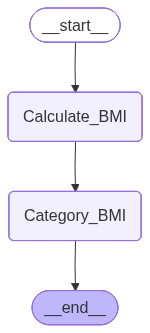

In [18]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())